In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

songs = pd.read_csv('dataset/songs.csv')

In [3]:
filtered = songs[
    (songs['popularity'] > 0) &
    (songs['lyrics'].notna()) &
    (songs['lyrics'].str.strip() != '') &
    (songs['year'] <= 2023)
].copy().reset_index(drop=True)
print('Filtered songs (popularity > 0, non-empty lyrics, tracks from 2023 and below)')
print(f'Rows   : {len(filtered):,}')
print(f'Columns: {filtered.shape[1]}')
display(filtered.head(3))

Filtered songs (popularity > 0, non-empty lyrics, tracks from 2023 and below)
Rows   : 363,056
Columns: 24


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,79.998,114000,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,"[""2jwRHcdgkRhelYEMqndDKe""]",[]
1,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,142.959,178533,"It's been a while, shit, I missed the rehab, p...",2018,Hip-Hop,43,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"
2,0sZb4GBh64F0FOZzQy6QqV,"""...Because All Suffering Is Sweet to Me...""",Lucy Gray,"[""Envy On The Coast""]",0.241,0.734,4,-6.919,0,0.0671,...,157.355,237973,You're not supposed to know this.\nYou're not ...,2007,Rock,23,37014,31.0,"[""6RvruFAgvsAb4B82u8wsSH""]","[""post-hardcore""]"


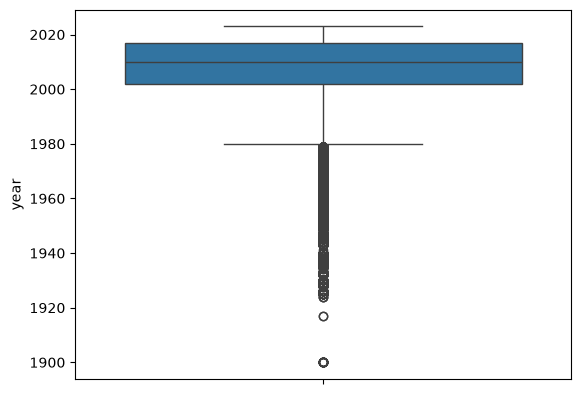

In [4]:
sns.boxplot(data=filtered, y='year')
plt.show()

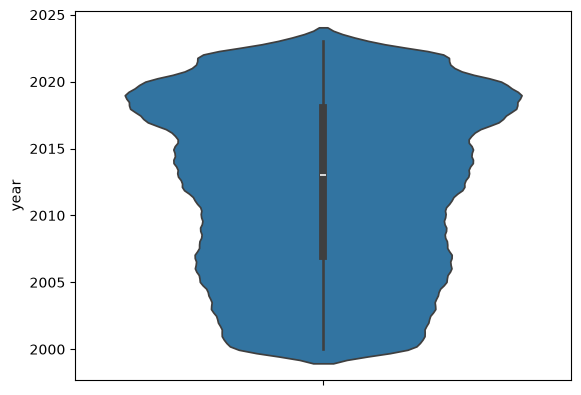

In [5]:
sns.violinplot(data=filtered[filtered['year'] >= 2000], y='year')
plt.show()

---
## 1. Year Range Comparisons

In [6]:
year_ranges = ['2021-2023', '2016-2023', '2013-2023', '2010-2023', '2000-2023']
years_min = [2021, 2016, 2013, 2010, 2000]
cols = ['popularity', 'valence']

# filtering year ranges
filtered_list = []

for i, year in enumerate(years_min):
    filtered_list.append(filtered[filtered['year'] >= year].copy().reset_index(drop=True))
    print(f'\n({year_ranges[i]})\tRecords: {len(filtered_list[i]):,}')
    display(filtered_list[i][cols].describe())


(2021-2023)	Records: 27,084


,popularity,valence
count,27084.000000,27084.000000
mean,30.013440,0.431159
std,16.130456,0.232332
min,1.000000,0.025900
25%,18.000000,0.242000
50%,30.000000,0.409000
75%,41.000000,0.602250
max,85.000000,0.987000



(2016-2023)	Records: 109,059


,popularity,valence
count,109059.000000,109059.000000
mean,27.935191,0.426560
std,16.266838,0.233503
min,1.000000,0.018100
25%,16.000000,0.236000
50%,27.000000,0.401000
75%,39.000000,0.597000
max,91.000000,0.993000



(2013-2023)	Records: 149,684


,popularity,valence
count,149684.000000,149684.000000
mean,26.876126,0.427624
std,16.176064,0.236092
min,1.000000,0.000000
25%,14.000000,0.235000
50%,26.000000,0.400000
75%,38.000000,0.601000
max,96.000000,0.993000



(2010-2023)	Records: 185,121


,popularity,valence
count,185121.000000,185121.000000
mean,26.008016,0.431093
std,16.122479,0.238023
min,1.000000,0.000000
25%,13.000000,0.236000
50%,24.000000,0.405000
75%,37.000000,0.607000
max,96.000000,0.996000



(2000-2023)	Records: 290,569


,popularity,valence
count,290569.000000,290569.000000
mean,24.149675,0.446878
std,16.024434,0.243670
min,1.000000,0.000000
25%,11.000000,0.246000
50%,22.000000,0.424000
75%,35.000000,0.633000
max,96.000000,0.996000


C:\Users\GrenAppl\AppData\Local\Temp\ipykernel_17832\80111939.py:39: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
d:\Code\git\THESIS\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


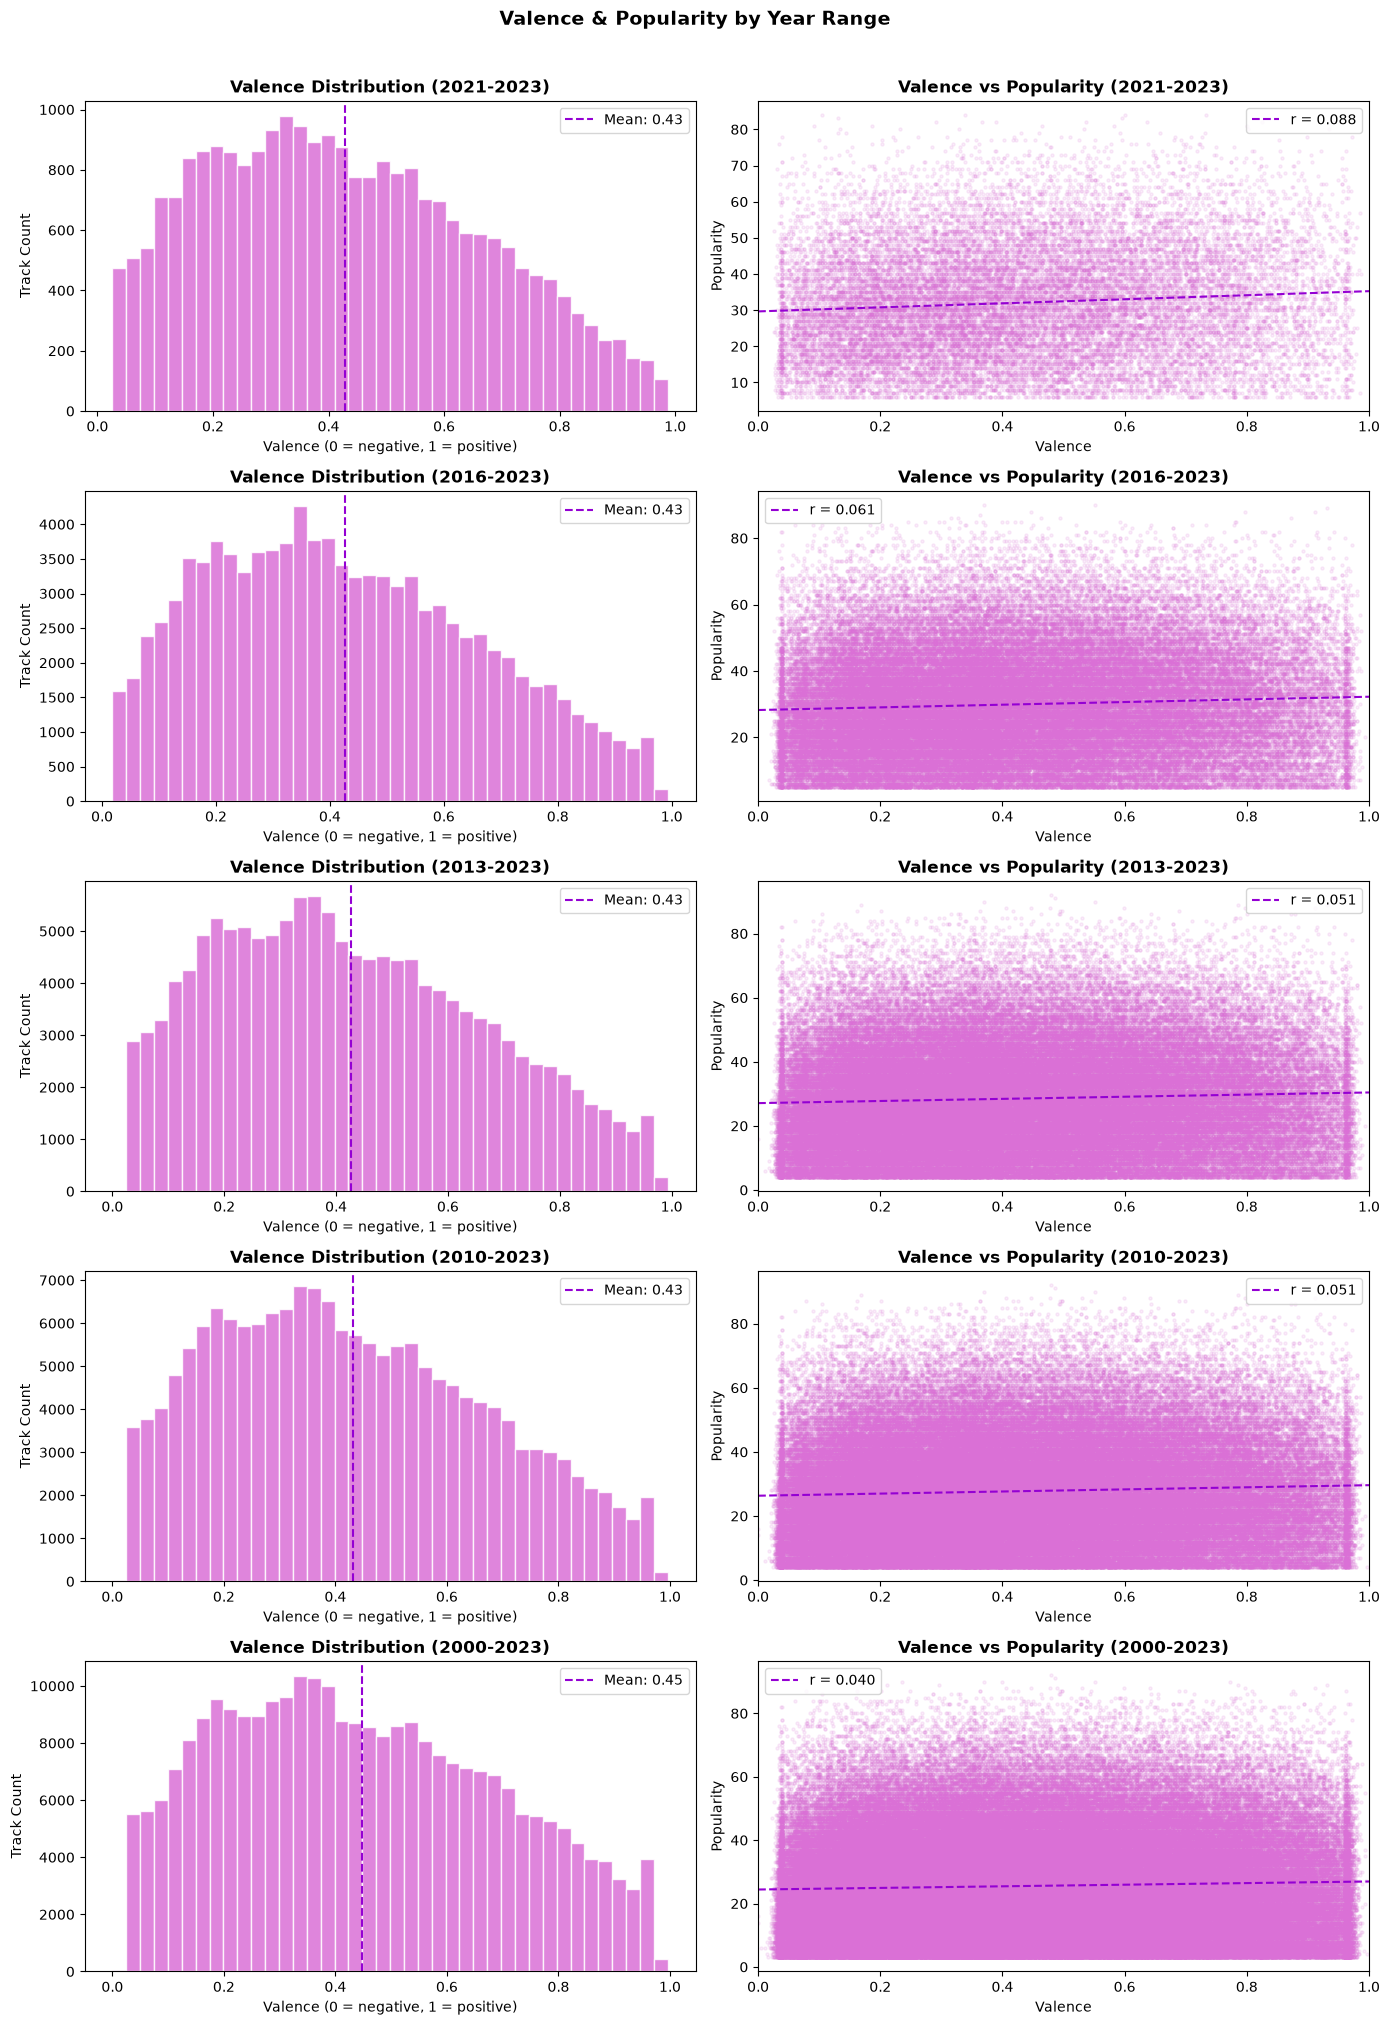

In [16]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))

for i, (f, yr) in enumerate(zip(filtered_list, year_ranges)):

    ax_hist = axes[i, 0]   # left column  → valence distribution
    ax_scat = axes[i, 1]   # right column → valence vs popularity

    # ── Valence distribution ──────────────────────────────────────────────────
    ax_hist.hist(f['valence'], bins=40, color='orchid',
                 edgecolor='white', alpha=0.85)
    ax_hist.axvline(f['valence'].mean(), color='darkviolet',
                    linestyle='--',
                    label=f'Mean: {f["valence"].mean():.2f}')
    ax_hist.set_title(f'Valence Distribution ({yr})', fontweight='bold')
    ax_hist.set_xlabel('Valence (0 = negative, 1 = positive)')
    ax_hist.set_ylabel('Track Count')
    ax_hist.legend()

    # Valence vs Popularity scatter
    ax_scat.scatter(f['valence'], f['popularity'],
                    alpha=0.12, s=5, color='orchid')

    # Trend line so the relationship is easier to read
    z = np.polyfit(f['valence'], f['popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, 1, 100)
    ax_scat.plot(x_line, p(x_line), color='darkviolet',
                 linewidth=1.5, linestyle='--',
                 label=f'r = {f["valence"].corr(f["popularity"]):.3f}')

    ax_scat.set_title(f'Valence vs Popularity ({yr})', fontweight='bold')
    ax_scat.set_xlabel('Valence')
    ax_scat.set_ylabel('Popularity')
    ax_scat.set_xlim(0, 1)
    ax_scat.legend()

plt.suptitle('Valence & Popularity by Year Range', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Data Cleaning and Features

In [8]:
for i, _ in enumerate(filtered_list):
    # lyrics
    filtered_list[i]['lyrics'] = filtered_list[i]['lyrics'].str.lower() \
                                    .str.encode('utf-8').str.decode('unicode_escape')
    
    # valence normalized
    filtered_list[i]['valence_norm'] = filtered_list[i]['valence'] * 2 - 1 

    # popularity logged
    filtered_list[i]['popularity_log'] = np.log1p(filtered_list[i]['popularity'])

In [43]:
# lyrics and valence check
print('=== BEFORE ===')
print(filtered['lyrics'][0][:300])

print('\n=== AFTER ===')
print(filtered_list[1]['lyrics'][0][:300])

for i, f in enumerate(filtered_list):
    print(f'\n({year_ranges[i]})')
    display(f[['valence', 'valence_norm']].head())

=== BEFORE ===
Fuck the bitch, now she running with my kids\nAnd you said I never listen\nYeah, yeah\nYeah, yeah, yeah\nTell me all the things 'bout your family\nStruggle with your words, said you're rambling\nAlways play a game, bet you're gambling\nBut you got me on a string and I'm dancing\nTell me your childho

=== AFTER ===
fuck the bitch, now she running with my kids
and you said i never listen
yeah, yeah
yeah, yeah, yeah
tell me all the things 'bout your family
struggle with your words, said you're rambling
always play a game, bet you're gambling
but you got me on a string and i'm dancing
tell me your childhood tv sh

(2021-2023)


,valence,valence_norm
0,0.6030,0.206
1,0.8070,0.614
2,0.3490,-0.302
3,0.3280,-0.344
4,0.0385,-0.923



(2016-2023)


,valence,valence_norm
0,0.287,-0.426
1,0.688,0.376
2,0.324,-0.352
3,0.714,0.428
4,0.603,0.206



(2013-2023)


,valence,valence_norm
0,0.287,-0.426
1,0.688,0.376
2,0.324,-0.352
3,0.714,0.428
4,0.198,-0.604



(2010-2023)


,valence,valence_norm
0,0.287,-0.426
1,0.688,0.376
2,0.324,-0.352
3,0.423,-0.154
4,0.714,0.428



(2000-2023)


,valence,valence_norm
0,0.287,-0.426
1,0.688,0.376
2,0.040,-0.920
3,0.324,-0.352
4,0.423,-0.154


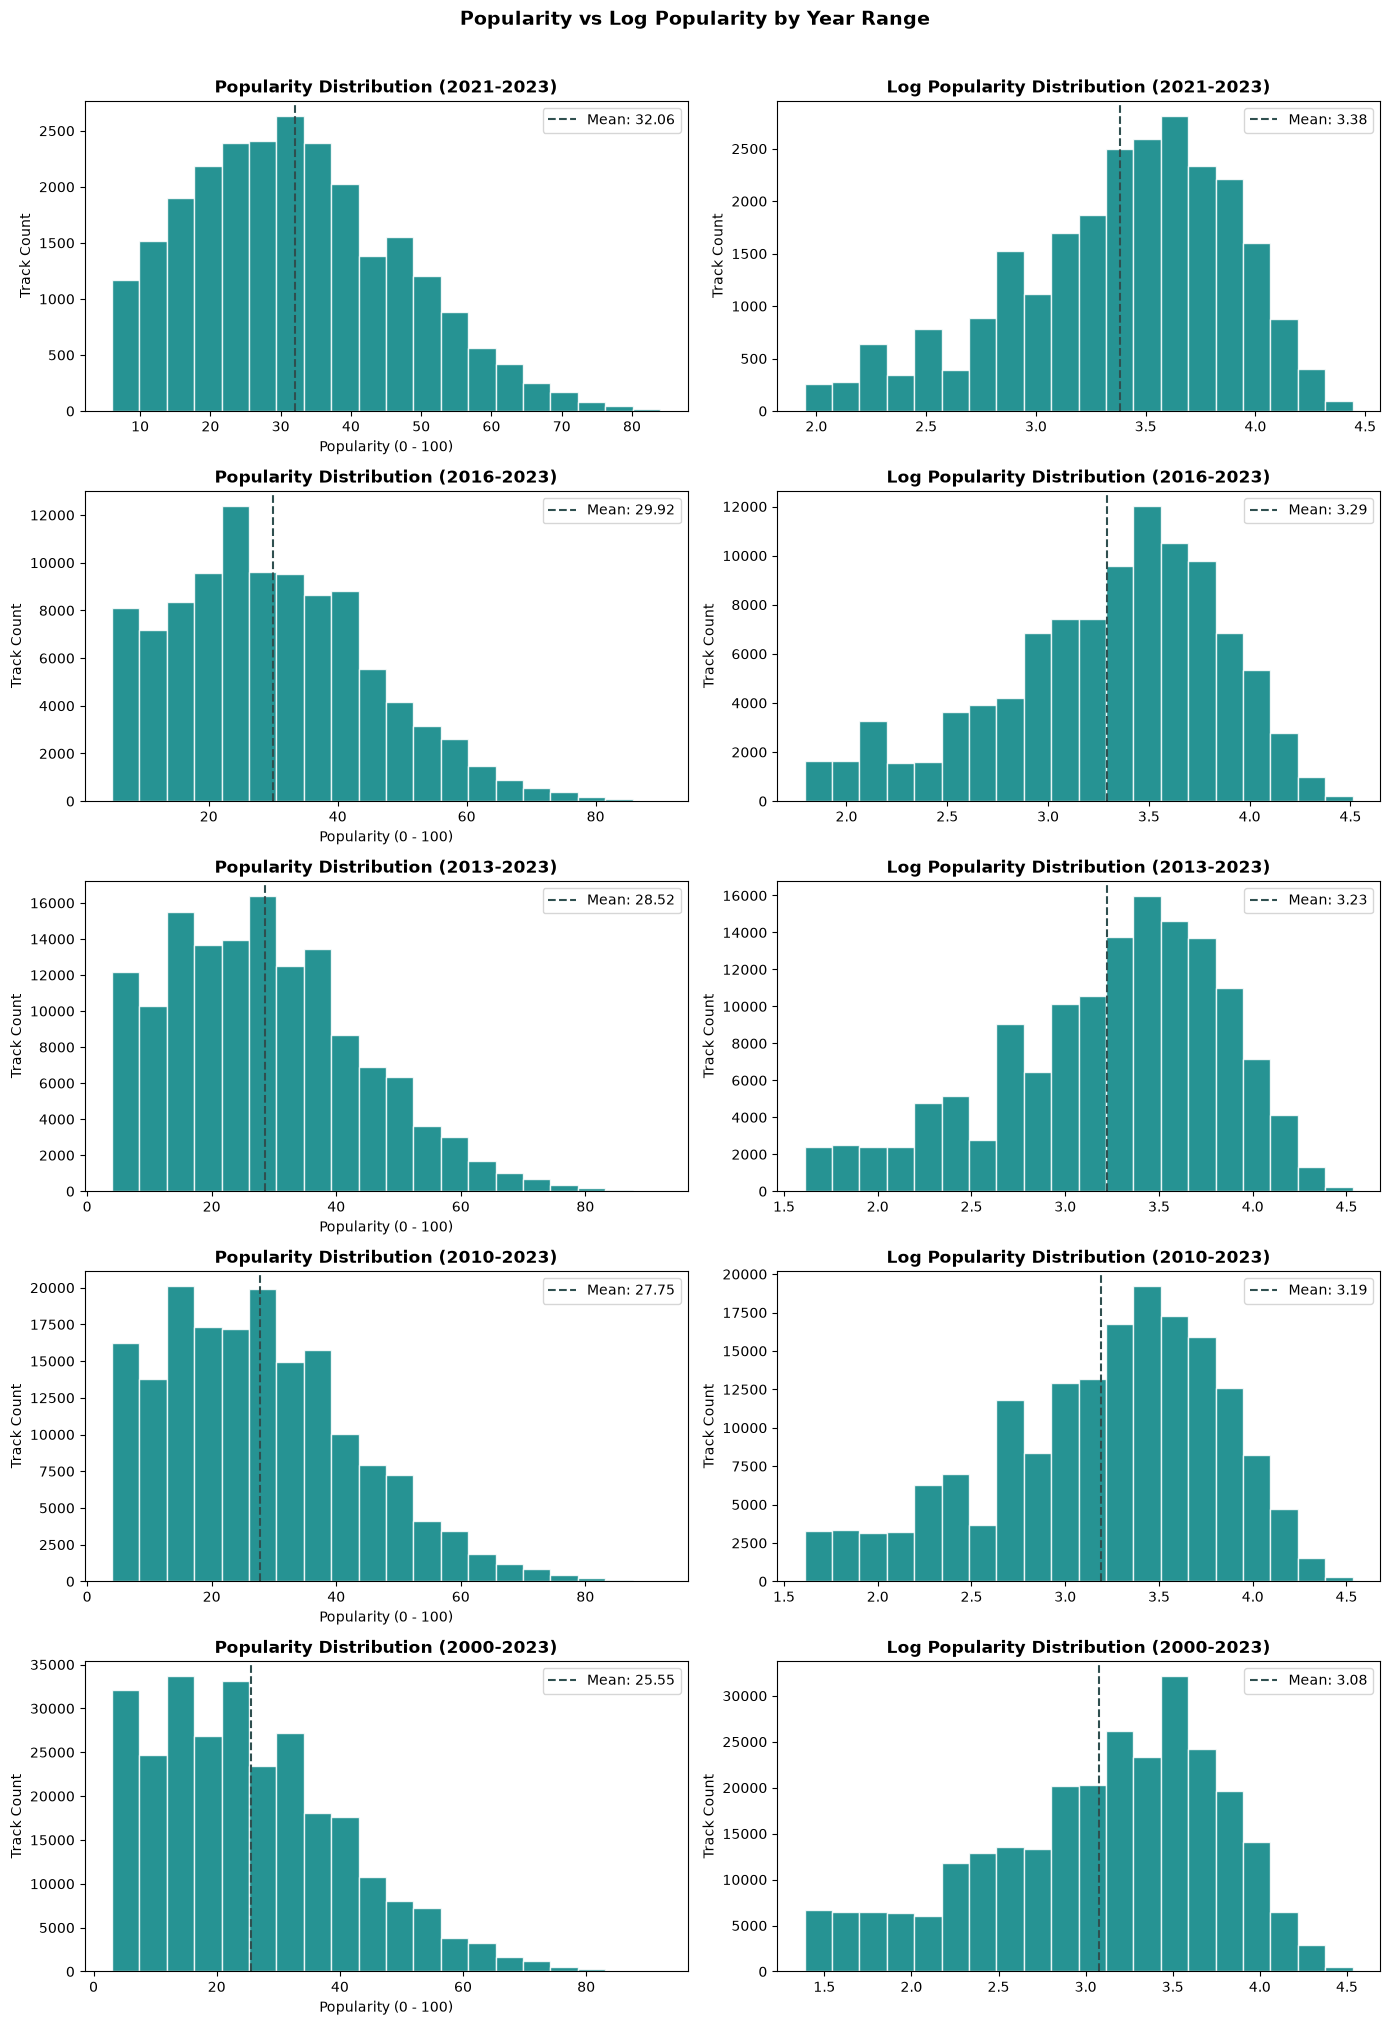

In [15]:
# log popularity check
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
bins = 20

for i, (f, yr) in enumerate(zip(filtered_list, year_ranges)):

    ax_pop = axes[i, 0]
    ax_pop_log = axes[i, 1]

    # Popularity distribution
    ax_pop.hist(f['popularity'], bins=bins, color='teal',
                 edgecolor='white', alpha=0.85)
    ax_pop.axvline(f['popularity'].mean(), color='darkslategray',
                    linestyle='--',
                    label=f'Mean: {f["popularity"].mean():.2f}')
    ax_pop.set_title(f'Popularity Distribution ({yr})', fontweight='bold')
    ax_pop.set_xlabel('Popularity (0 - 100)')
    ax_pop.set_ylabel('Track Count')
    ax_pop.legend()

    # Log Popularity
    ax_pop_log.hist(f['popularity_log'], bins=bins, color='teal',
                 edgecolor='white', alpha=0.85)
    ax_pop_log.axvline(f['popularity_log'].mean(), color='darkslategray',
                    linestyle='--',
                    label=f'Mean: {f["popularity_log"].mean():.2f}')
    ax_pop_log.set_title(f'Log Popularity Distribution ({yr})', fontweight='bold')
    ax_pop_log.set_ylabel('Track Count')
    ax_pop_log.legend()

plt.suptitle('Popularity vs Log Popularity by Year Range', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

(2021-2023)
Lower Whisker End: 2.3978952727983707
Upper Whisker End: 4.418840607796598

(2016-2023)
Lower Whisker End: 2.0794415416798357
Upper Whisker End: 4.48863636973214

(2013-2023)
Lower Whisker End: 2.0794415416798357
Upper Whisker End: 4.51085950651685

(2010-2023)
Lower Whisker End: 1.9459101490553132
Upper Whisker End: 4.51085950651685

(2000-2023)
Lower Whisker End: 1.791759469228055
Upper Whisker End: 4.51085950651685



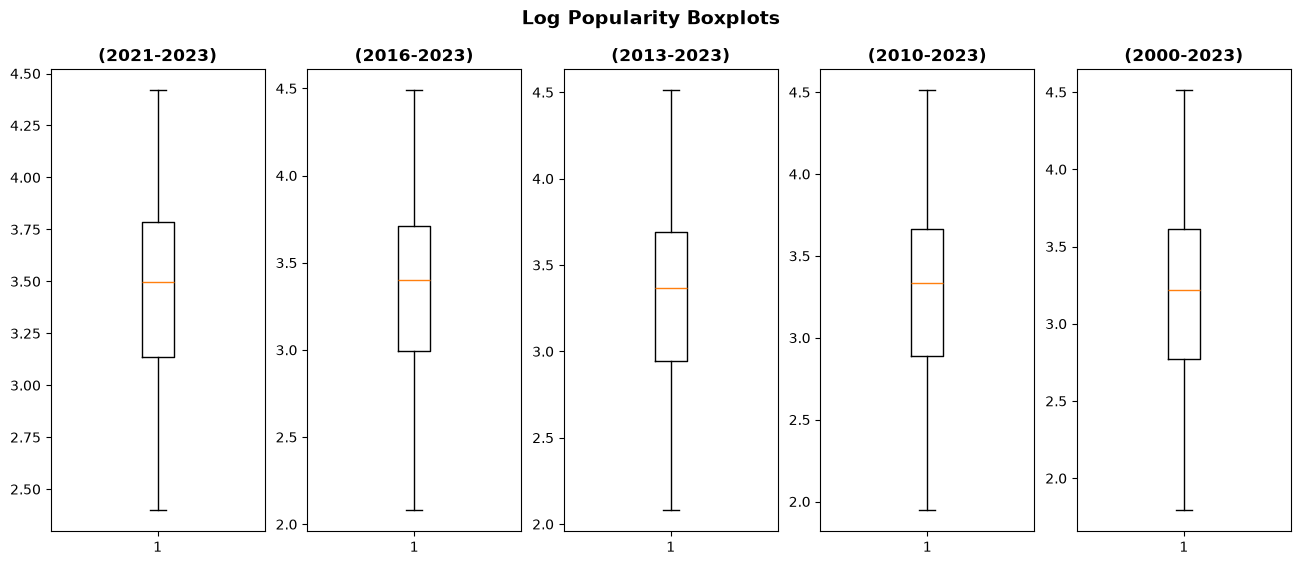

In [26]:
# check popularity outliers
fig, ax = plt.subplots(1, 5, figsize=(16, 6))
lower_whiskers = []
upper_whiskers = []

for i, (f, yr) in enumerate(zip(filtered_list, year_ranges)):
    bp_dict = ax[i].boxplot(f['popularity_log'])
    ax[i].set_title(f'({yr})', fontweight='bold')

    # Whiskers come in pairs per column: [lower_whisker, upper_whisker]
    whiskers = [whisker.get_ydata() for whisker in bp_dict["whiskers"]]

    # Get the values where the whiskers end
    lower_whiskers.append(whiskers[0][1])
    upper_whiskers.append(whiskers[1][1])

    print(f'({yr})')
    print(f"Lower Whisker End: {lower_whiskers[i]}")
    print(f"Upper Whisker End: {upper_whiskers[i]}")
    print()

plt.suptitle('Log Popularity Boxplots', fontsize=14, fontweight='bold')
plt.show()

In [29]:
# check pop log stats

for i, f in enumerate(filtered_list):
    print(f'({year_ranges[i]})')
    display(f['popularity_log'].describe())
    print('Coefficient of Variation (std / mean): ' + str(f['popularity_log'].std() / f['popularity_log'].mean()))
    print('Records below lower whisker: ' + str(len(f[f['popularity_log'] <= lower_whiskers[i]])))
    print('Records above upper whisker: ' + str(len(f[f['popularity_log'] >= upper_whiskers[i]])))
    print()

(2021-2023)


count    24013.000000
mean         3.442244
std          0.440609
min          2.397895
25%          3.135494
50%          3.496508
75%          3.784190
max          4.418841
Name: popularity_log, dtype: float64

Coefficient of Variation (std / mean): 0.12800039090008725
Records below lower whisker: 339
Records above upper whisker: 7

(2016-2023)


count    97947.000000
mean         3.337993
std          0.511189
min          2.079442
25%          2.995732
50%          3.401197
75%          3.713572
max          4.488636
Name: popularity_log, dtype: float64

Coefficient of Variation (std / mean): 0.15314250512825842
Records below lower whisker: 1599
Records above upper whisker: 3

(2013-2023)


...

Coefficient of Variation (std / mean): 0.15648975269941476
Records below lower whisker: 2422
Records above upper whisker: 2

(2010-2023)


count    166031.000000
mean          3.252985
std           0.548180
min           1.945910
25%           2.890372
50%           3.332205
75%           3.663562
max           4.510860
Name: popularity_log, dtype: float64

Coefficient of Variation (std / mean): 0.16851592498048354
Records below lower whisker: 3180
Records above upper whisker: 2

(2000-2023)


count    260558.000000
mean          3.157529
std           0.598549
min           1.791759
25%           2.772589
50%           3.218876
75%           3.610918
max           4.510860
Name: popularity_log, dtype: float64

Coefficient of Variation (std / mean): 0.1895624331758734
Records below lower whisker: 6496
Records above upper whisker: 5



In [24]:
# removes outliers based on pop log
for i in range(len(filtered_list)):
    print(f'({year_ranges[i]})')

    print('OLD -> ' + str(len(filtered_list[i])))
    filtered_list[i] = filtered_list[i][filtered_list[i]['popularity_log'] > lower_whiskers[i]]
    filtered_list[i] = filtered_list[i][filtered_list[i]['popularity_log'] < upper_whiskers[i]]

    print('NEW -> ' + str(len(filtered_list[i])))
    print()

(2021-2023)
OLD -> 24325
NEW -> 24013

(2016-2023)
OLD -> 99576
NEW -> 97947

(2013-2023)
OLD -> 135550
NEW -> 133140

(2010-2023)
OLD -> 169401
NEW -> 166031

(2000-2023)
OLD -> 266996
NEW -> 260558



---
## 3. Save Filtered Songs

In [ ]:
from math import ceil
from pathlib import Path

records = 25000
for i, f in enumerate(filtered_list):
    path = f'filtered/songs_{year_ranges[i]}'
    if len(f) <= records:
        f.to_csv(f'{path}.csv')
    else:
        Path(path).mkdir(parents=True, exist_ok=True)
        total_parts = ceil(len(f) / records)

        for i in range(total_parts):
            f[(records * i): (records * i + records)].to_csv(f'{path}/{i + 1}.csv')